# Lesson 1 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skripiy/ida-practice-3d/blob/main/practice/1/1-homework-results.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives you a function signature and a docstring stating exactly
what the function must return. Replace the `raise NotImplementedError` with
your implementation. The cell immediately after each task contains
`assert` statements that check your work.

**A failing assert is information, not a grade.** It tells you that the
behaviour does not yet match the contract. Read the assertion message, fix
the function, re-run the cell. There is no penalty for running a cell
twenty times.

The written questions are marked. They are the part of this homework that
carries the learning objective: each one asks you to *run something both
ways and explain the difference*, not to recall a fact. Answers of one
sentence will not be enough; answers of one paragraph, referring to numbers
you actually produced, will.

Every function you need has been demonstrated in `1-practice.ipynb`. Each
task names the section — `see Practice 1 §3.6` — where the relevant material
is. You should not need any other documentation, and you should not need to
search the internet. If you find yourself wanting to, the reference is
probably in the practice notebook and worth finding.

## Before you submit

**Runtime → Restart and run all must complete without error**, with every
assert passing. A notebook that only works because you ran the cells in an
unusual order is not reproducible, and reproducibility is the subject of
§4.1 of the practice notebook.

Then **File → Download → Download .ipynb**, rename the file to
`1-homework-results.ipynb`, and commit it to your fork under
`practice/1/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

Run this first. It is the same configuration cell as the practice notebook.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

SEED = 20250919
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["lines.linewidth"] = 2.0

print("python", sys.version.split()[0], "| numpy", np.__version__)

python 3.14.5 | numpy 2.4.6


## 2. Task 1 — Describe an array

Mechanical. Return the five attributes that describe an array's layout.

*see Practice 1 §3.2*

In [2]:
def describe_array(arr):
    """Return a dict describing the memory layout of `arr`.

    Keys, exactly these five:
        'dtype'    the element type, as a string (use str(...) on the dtype)
        'shape'    the shape, as a tuple
        'ndim'     the number of dimensions, as an int
        'size'     the total number of elements, as an int
        'nbytes'   the total number of bytes occupied by the data, as an int

    No allocation and no copying: read the attributes off `arr`.
    """
    return {
        "dtype": str(arr.dtype),
        "shape": tuple(arr.shape),
        "ndim": int(arr.ndim),
        "size": int(arr.size),
        "nbytes": int(arr.nbytes),
    }


In [3]:
_result = describe_array(np.zeros((3, 4), dtype=np.float64))
assert set(_result) == {"dtype", "shape", "ndim", "size", "nbytes"}, \
    f"expected exactly those five keys, got {sorted(_result)}"
assert _result["shape"] == (3, 4), f"shape wrong: {_result['shape']}"
assert _result["ndim"] == 2, f"ndim wrong: {_result['ndim']}"
assert _result["size"] == 12, f"size wrong: {_result['size']}"
assert _result["nbytes"] == 96, f"nbytes wrong: {_result['nbytes']} (12 elements x 8 bytes)"
assert "float64" in _result["dtype"], f"dtype wrong: {_result['dtype']}"

_int_result = describe_array(np.arange(10, dtype=np.int32))
assert _int_result["nbytes"] == 40, "an int32 array of 10 elements occupies 40 bytes"
assert _int_result["ndim"] == 1

print("Task 1 passed.")

Task 1 passed.


## 3. Task 2 — A view bug, and the fix

The function below is supposed to return a copy of the middle of an array
with its values clipped to zero, leaving the caller's array untouched. It
does not. Find the defect and repair it.

Do not change the signature and do not change what the function returns —
only make it stop modifying its argument.

*see Practice 1 §3.6*

In [4]:
def zero_the_middle(arr, start, stop):
    """Return a NEW array holding arr[start:stop] with every value set to 0.

    `arr` must not be modified. The returned array must have length
    stop - start and must not share memory with `arr`.

    The defect: `arr[start:stop]` is a VIEW, not a copy, so `middle[:] = 0`
    wrote zeros straight into the caller's array. Taking an explicit copy
    first gives the slice its own buffer, so the assignment cannot reach
    back into `arr`.
    """
    middle = arr[start:stop].copy()
    middle[:] = 0
    return middle


In [5]:
_original = np.arange(10)
_untouched = np.arange(10)
_returned = zero_the_middle(_original, 3, 6)

assert np.array_equal(_original, _untouched), \
    f"the argument was modified: {_original} should still be {_untouched}"
assert _returned.shape == (3,), f"wrong length: {_returned.shape}"
assert np.all(_returned == 0), f"values not zeroed: {_returned}"
assert not np.shares_memory(_returned, _original), \
    "the result still shares memory with the argument"

print("Task 2 passed.")

Task 2 passed.


## 4. Task 3 — Standardise the columns of a matrix

Applied. Subtract each column's mean and divide by each column's standard
deviation, using broadcasting rather than a loop over columns.

This is what `StandardScaler` does, and Practice 2 §9 will use the
scikit-learn object. Writing it once by hand is the point.

*see Practice 1 §3.7 and §3.8*

In [6]:
def standardise_columns(matrix):
    """Return `matrix` with every column centred and scaled to unit variance.

    For each column j:  out[:, j] = (matrix[:, j] - mean_j) / sd_j

    Use the population standard deviation (NumPy's default, ddof=0).
    The result has the same shape as `matrix`. Do not modify `matrix`.
    Use broadcasting; do not write a `for` loop over the columns.
    """
    means = matrix.mean(axis=0)   # shape (n_columns,)
    sds = matrix.std(axis=0)      # shape (n_columns,), ddof=0
    # (n_rows, n_cols) - (n_cols,) broadcasts the row vector down every row,
    # so one expression standardises all columns at once.
    return (matrix - means) / sds


In [7]:
_data = np.array([[1.0, 100.0],
                  [2.0, 200.0],
                  [3.0, 300.0],
                  [4.0, 400.0]])
_before = _data.copy()
_scaled = standardise_columns(_data)

assert _scaled.shape == _data.shape, f"shape changed: {_scaled.shape}"
assert np.array_equal(_data, _before), "the input matrix was modified"
assert np.allclose(_scaled.mean(axis=0), 0.0), \
    f"columns not centred, means are {_scaled.mean(axis=0)}"
assert np.allclose(_scaled.std(axis=0), 1.0), \
    f"columns not unit variance, sds are {_scaled.std(axis=0)}"
# The two columns are the same numbers on different scales, so after
# standardising they must be identical.
assert np.allclose(_scaled[:, 0], _scaled[:, 1]), \
    "a linear rescaling of a column should standardise to the same values"

_wide = rng.normal(5.0, 3.0, size=(200, 7))
assert np.allclose(standardise_columns(_wide).mean(axis=0), 0.0, atol=1e-12)
assert np.allclose(standardise_columns(_wide).std(axis=0), 1.0)

print("Task 3 passed.")

Task 3 passed.


## 5. Task 4 — Reductions along an axis

Mechanical, but the axis argument is the thing being tested. Read the
docstring carefully: two of these collapse rows and two collapse columns.

*see Practice 1 §3.8*

In [8]:
def axis_summary(matrix):
    """Return a dict of four reductions of a 2-D array.

    Keys and contents:
        'per_column_mean'  one value per COLUMN, shape (n_columns,)
        'per_row_sum'      one value per ROW,    shape (n_rows,)
        'per_row_max'      one value per ROW,    shape (n_rows,)
        'grand_total'      the sum of every element, a scalar float

    Return NumPy arrays for the first three and a Python/NumPy float for
    the last.
    """
    # axis=0 collapses the rows, leaving one number per column.
    # axis=1 collapses the columns, leaving one number per row.
    return {
        "per_column_mean": matrix.mean(axis=0),
        "per_row_sum": matrix.sum(axis=1),
        "per_row_max": matrix.max(axis=1),
        "grand_total": float(matrix.sum()),
    }


In [9]:
_grid = np.array([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
_summary = axis_summary(_grid)

assert _summary["per_column_mean"].shape == (3,), \
    f"per_column_mean should have one value per column: {_summary['per_column_mean'].shape}"
assert np.allclose(_summary["per_column_mean"], [2.5, 3.5, 4.5])
assert _summary["per_row_sum"].shape == (2,), \
    f"per_row_sum should have one value per row: {_summary['per_row_sum'].shape}"
assert np.allclose(_summary["per_row_sum"], [6.0, 15.0])
assert np.allclose(_summary["per_row_max"], [3.0, 6.0])
assert np.isclose(_summary["grand_total"], 21.0)

# A non-square array catches an axis swapped by accident.
_tall = rng.normal(size=(50, 4))
_tall_summary = axis_summary(_tall)
assert _tall_summary["per_column_mean"].shape == (4,)
assert _tall_summary["per_row_sum"].shape == (50,)

print("Task 4 passed.")

Task 4 passed.


### Question 1 — the axis argument

Take the `(50, 4)` array `_tall` from the cell above. Compute `_tall.sum()`,
`_tall.sum(axis=0)` and `_tall.sum(axis=1)`, and print the shape of each.

Explain, in your own words, **why `axis=0` produces four numbers and not
fifty**, given that the array has fifty rows. Then state which of the three
you would use to answer the question "what is the average value of each
feature across all samples", and why.

In [10]:
total = _tall.sum()
by_axis0 = _tall.sum(axis=0)
by_axis1 = _tall.sum(axis=1)

print("_tall.shape       ", _tall.shape)
print("_tall.sum()        ->", np.shape(total), " value", round(float(total), 4))
print("_tall.sum(axis=0)  ->", by_axis0.shape, "\n", np.round(by_axis0, 4))
print("_tall.sum(axis=1)  ->", by_axis1.shape, "first five", np.round(by_axis1[:5], 4))

# The mean of each feature across all samples:
print("\nper-feature mean  ->", np.round(_tall.mean(axis=0), 4), "shape", _tall.mean(axis=0).shape)


_tall.shape        (50, 4)
_tall.sum()        -> ()  value -9.7922
_tall.sum(axis=0)  -> (4,) 
 [-8.0218 -0.81    8.2115 -9.1719]
_tall.sum(axis=1)  -> (50,) first five [-0.5051 -2.0902  0.158   0.2296 -0.4013]

per-feature mean  -> [-0.1604 -0.0162  0.1642 -0.1834] shape (4,)


**Answer:**

`_tall.sum()` returns a scalar of shape `()` — the value `-9.7922`.
`_tall.sum(axis=0)` returns shape `(4,)`: `[-8.0218, -0.8100, 8.2115, -9.1719]`.
`_tall.sum(axis=1)` returns shape `(50,)`, beginning `[-0.5051, -2.0902, 0.1580, 0.2296, -0.4013]`.

**Why `axis=0` gives four numbers and not fifty.** The `axis` argument names
the axis the reduction *consumes*, not the axis it reports along. `_tall` has
shape `(50, 4)`; axis 0 is the one of length 50. `sum(axis=0)` walks down that
axis and adds all fifty entries together, so axis 0 disappears from the result
and what remains is the other axis, of length 4 — one total per column. The
rule is mechanical: the output shape is the input shape with the named axis
deleted, `(50, 4)` minus axis 0 is `(4,)`, and `(50, 4)` minus axis 1 is
`(50,)`. `sum()` with no axis consumes both and leaves `()`, a scalar. The
phrase "sum over axis 0" is worth reading as "sum *away* axis 0"; the common
error is reading it as "sum along the rows" and expecting fifty numbers.

**For "the average value of each feature across all samples".** In this array
each row is a sample and each column is a feature, so a per-feature answer must
have one number per column — four numbers — and to get them I have to collapse
the fifty samples, which is axis 0. So `_tall.mean(axis=0)`, which gives
`[-0.1604, -0.0162, 0.1642, -0.1834]`, shape `(4,)`. `axis=1` would answer a
different and usually meaningless question: the average of one sample's four
features, which mixes quantities that may be in different units. The check I
use is the shape: an answer about features must have `n_features` entries, and
here `(4,)` is right while `(50,)` is not.


## 6. Task 5 — Outliers by the k-sigma rule

Applied. Generalise the practice notebook's 3σ filter to an arbitrary threshold.

*see Practice 1 §3.9 and §4.7*

In [11]:
def sigma_outliers(sample, k=3.0):
    """Flag the values of `sample` that lie more than k standard deviations
    from the sample mean.

    Use the mean and standard deviation OF THE SAMPLE itself, not assumed
    values, and NumPy's default ddof=0 for the standard deviation.

    Return a tuple (mask, values):
        mask    a boolean array, the same shape as `sample`, True where the
                value is an outlier
        values  the outlying values themselves, in their original order

    Build the mask with a vectorised comparison; do not loop.
    """
    mu = sample.mean()
    sd = sample.std()  # ddof=0
    # One vectorised comparison over the whole array; no Python loop.
    mask = np.abs(sample - mu) > k * sd
    values = sample[mask]  # boolean indexing keeps the original order
    return mask, values


In [12]:
_plain = np.array([1.0, 2.0, 3.0, 2.0, 1.0, 50.0])
_mask, _values = sigma_outliers(_plain, k=2.0)

assert _mask.dtype == bool, f"mask must be boolean, got {_mask.dtype}"
assert _mask.shape == _plain.shape, f"mask shape {_mask.shape} != sample shape {_plain.shape}"
assert _mask.sum() == 1, f"expected exactly one outlier at k=2, found {_mask.sum()}"
assert np.allclose(_values, [50.0]), f"wrong value flagged: {_values}"

# On a clean normal sample the 3-sigma rule should flag very few points.
_normal = rng.normal(0.0, 1.0, 10_000)
_normal_mask, _ = sigma_outliers(_normal, k=3.0)
_rate = _normal_mask.mean()
assert 0.0 < _rate < 0.01, \
    f"flag rate {_rate:.4f} is implausible for 3 sigma on normal data (expect ~0.0027)"

# A larger threshold can never flag more points than a smaller one.
assert sigma_outliers(_normal, k=4.0)[0].sum() <= _normal_mask.sum()

print(f"Task 5 passed. 3-sigma flag rate on 10,000 normal draws: {_rate:.4%}")

Task 5 passed. 3-sigma flag rate on 10,000 normal draws: 0.3100%


### Question 2 — the threshold is a choice

Using the 10 000-point normal sample `_normal`, run `sigma_outliers` at
`k = 1, 2, 3, 4, 5` and print the number of points flagged at each.

Then answer: the theoretical fractions outside k standard deviations of a
normal distribution are about 32 %, 4.6 %, 0.27 %, 0.0063 % and 0.000057 %.
Compare your counts with those. **At which k does the sample stop having
enough data to estimate the rate at all**, and what does that imply about
using a very large k to define an outlier?

Finally: none of the points in `_normal` is an error — they all came from
the same generator. Describe one concrete situation in which you *would* be
justified in deleting a flagged point, and say what evidence would justify
it.

In [13]:
theoretical = {1: 31.7310, 2: 4.5500, 3: 0.2700, 4: 0.0063, 5: 0.000057}

print(f"n = {_normal.size:,}   mean = {_normal.mean():.4f}   sd = {_normal.std():.4f}\n")
print(f"{'k':>2} {'flagged':>8} {'observed %':>12} {'theory %':>12} {'theory count':>14}")
for k in (1, 2, 3, 4, 5):
    m, _ = sigma_outliers(_normal, k=float(k))
    count = int(m.sum())
    expected = theoretical[k] / 100 * _normal.size
    print(f"{k:>2} {count:>8} {100 * count / _normal.size:>11.4f}% {theoretical[k]:>11.4f}% {expected:>14.4f}")


n = 10,000   mean = -0.0117   sd = 1.0101

 k  flagged   observed %     theory %   theory count
 1     3163     31.6300%     31.7310%      3173.1000
 2      454      4.5400%      4.5500%       455.0000
 3       31      0.3100%      0.2700%        27.0000
 4        2      0.0200%      0.0063%         0.6300
 5        0      0.0000%      0.0001%         0.0057


**Answer:**

The sample has mean `-0.0117` and sd `1.0101`, and the counts are:

| k | flagged | observed | theory | expected count |
|---|---|---|---|---|
| 1 | 3163 | 31.63 % | 31.73 % | 3173.1 |
| 2 | 454 | 4.54 % | 4.55 % | 455.0 |
| 3 | 31 | 0.31 % | 0.27 % | 27.0 |
| 4 | 2 | 0.02 % | 0.0063 % | 0.63 |
| 5 | 0 | 0.00 % | 0.000057 % | 0.0057 |

At k = 1 and k = 2 the agreement is very close — 3163 against 3173 and 454
against 455, errors of a few tenths of a percent relative. At k = 3 the match is
still reasonable in absolute terms (31 against 27) but already 15 % out in
relative terms, because the whole estimate rests on 31 points.

**Where the sample stops being able to estimate the rate: k = 4.** The expected
count there is 0.63 points — less than one. A sample of 10 000 can only report
whole numbers, so the finest distinction it can draw in that region is "0 or 1
or 2", and the observed 2 is three times the expectation without anything being
wrong: at those counts the fluctuation is of the same size as the quantity. At
k = 5 it is worse still — the expected count is 0.0057, so the overwhelmingly
likely observation is exactly 0, and that is what I got. A zero is not evidence
that the tail is empty; it is evidence that 10 000 draws is about a factor of
20 000 too few to see it.

**What that implies about a large k.** A large threshold defines "outlier" in
terms of an event the sample contains no information about. The rule stops
being a measurement and becomes an extrapolation from the normal assumption —
and the tail is exactly where that assumption is least testable, since a
heavy-tailed and a normal distribution look identical in the middle and differ
only out there. There is a second, sharper problem: `sigma_outliers` estimates
the sd *from the sample itself*, and any genuinely extreme point inflates that
sd, pushing the threshold `k*sd` out past itself. The bigger k is, the more the
rule is dominated by the handful of points it is supposed to be judging. So a
large k does not give a stricter, safer definition of an outlier; it gives an
arbitrary one with no data behind it.

**When deleting a flagged point would be justified.** Not on the strength of
the flag: the flag says a value is unusual under an assumed distribution, never
that it is wrong. Every point in `_normal` came from one generator, so all 31
flagged at k = 3 are genuine data and deleting them would be falsifying the
sample — and it would not even end, since removing them shrinks the sd and the
rule immediately flags a new set.

A concrete case where I *would* delete: a temperature log in which a sensor
writes `-999` when it fails to read. Such a value is flagged, but the reason to
remove it is not the flag — it is the device's documentation stating `-999` is
a sentinel for "no reading", corroborated by the maintenance log showing the
sensor offline over exactly that interval, and by the value being physically
impossible for the quantity measured. That is the pattern: the justification
comes from evidence about the *measurement process* — an instrument range that
was exceeded, a unit that changed mid-collection (pounds recorded into a
kilograms column), a duplicated or misaligned record, a calibration failure with
a timestamp — and never from the number's distance from the mean. If I cannot
point to such evidence, the honest options are to keep the point, to report the
analysis with and without it, or to use a statistic that does not hinge on it,
not to delete it.


## 7. Task 6 — A NaN-aware mean, written by hand

Mechanical. Do not call `np.nanmean`; the point is to build it from the
masking tools.

*see Practice 1 §3.9 and §3.10*

In [14]:
def mean_ignoring_nan(sample):
    """Return the mean of the non-missing values of `sample`.

    Equivalent to np.nanmean, but you must implement it with np.isnan and
    boolean masking rather than calling any nan-aware NumPy reduction.

    If every value is missing, return np.nan.
    """
    present = ~np.isnan(sample)     # True where the value is not missing
    n_present = present.sum()
    if n_present == 0:
        return np.nan               # no values to average
    return sample[present].sum() / n_present


In [15]:
assert np.isclose(mean_ignoring_nan(np.array([1.0, 2.0, np.nan, 4.0])), 7.0 / 3.0)
assert np.isclose(mean_ignoring_nan(np.array([5.0, 5.0, 5.0])), 5.0)
assert np.isnan(mean_ignoring_nan(np.array([np.nan, np.nan]))), \
    "an all-missing sample has no mean; return np.nan"

_with_gaps = rng.normal(0.0, 1.0, 1000)
_with_gaps[rng.choice(1000, size=100, replace=False)] = np.nan
assert np.isclose(mean_ignoring_nan(_with_gaps), np.nanmean(_with_gaps)), \
    "your result should agree with np.nanmean"
assert np.isnan(_with_gaps.mean()), \
    "sanity check: the plain mean of an array containing NaN is NaN"

print("Task 6 passed.")

Task 6 passed.


## 8. Task 7 — How well does a sample know its own distribution

Applied. Draw samples of increasing size from a known normal distribution
and measure how far the estimated parameters fall from the true ones.

*see Practice 1 §4.1 and §4.6*

In [16]:
def recover_parameters(true_mu, true_sigma, sizes, generator):
    """Estimate mu and sigma from samples of several sizes.

    For each n in `sizes`, draw n values from normal(true_mu, true_sigma)
    using `generator`, and record the sample mean and the UNBIASED sample
    standard deviation (ddof=1).

    Draw the samples in the order the sizes are given, taking every sample
    from the same `generator` object, so that the result is reproducible
    for a given seed.

    Return a dict with three keys, each a NumPy array of len(sizes):
        'n'          the sample sizes, as given
        'mu_hat'     the estimated means
        'sigma_hat'  the estimated standard deviations
    """
    mu_hat = []
    sigma_hat = []
    for n in sizes:
        # One draw per size, from the same generator, in the given order:
        # that is what makes the whole result reproducible from one seed.
        sample = generator.normal(true_mu, true_sigma, n)
        mu_hat.append(sample.mean())
        sigma_hat.append(sample.std(ddof=1))
    return {
        "n": np.array(sizes),
        "mu_hat": np.array(mu_hat),
        "sigma_hat": np.array(sigma_hat),
    }


In [17]:
_sizes = [10, 100, 1_000, 10_000, 100_000]
_recovered = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))

assert set(_recovered) == {"n", "mu_hat", "sigma_hat"}
assert len(_recovered["mu_hat"]) == len(_sizes)
assert np.array_equal(_recovered["n"], np.array(_sizes))

# Reproducible: the same seed must give the same estimates.
_again = recover_parameters(2.0, 5.0, _sizes, np.random.default_rng(0))
assert np.allclose(_recovered["mu_hat"], _again["mu_hat"]), \
    "same seed gave different answers; are you drawing from the generator you were passed?"

# The largest sample must land close to the truth.
assert abs(_recovered["mu_hat"][-1] - 2.0) < 0.1, \
    f"mu estimate from 100,000 draws is {_recovered['mu_hat'][-1]:.4f}, expected near 2.0"
assert abs(_recovered["sigma_hat"][-1] - 5.0) < 0.1, \
    f"sigma estimate from 100,000 draws is {_recovered['sigma_hat'][-1]:.4f}, expected near 5.0"

# and the error should shrink as n grows
_err_small = abs(_recovered["mu_hat"][0] - 2.0)
_err_large = abs(_recovered["mu_hat"][-1] - 2.0)
assert _err_large < _err_small, "the estimate should improve with more data"

for n, mu, sd in zip(_recovered["n"], _recovered["mu_hat"], _recovered["sigma_hat"]):
    print(f"n = {n:7,}   mu_hat = {mu:8.4f}   sigma_hat = {sd:8.4f}")
print("\nTask 7 passed.")

n =      10   mu_hat =   2.4234   sigma_hat =   3.9067
n =     100   mu_hat =   2.2577   sigma_hat =   4.9827
n =   1,000   mu_hat =   1.7686   sigma_hat =   4.9318
n =  10,000   mu_hat =   2.0434   sigma_hat =   5.0002
n = 100,000   mu_hat =   1.9896   sigma_hat =   5.0035

Task 7 passed.


### Question 3 — the seed and the sample size

Two experiments.

**(a)** Call `recover_parameters(2.0, 5.0, [100], ...)` with five *different*
seeds. Record the five estimates of mu. How much do they vary?

**(b)** Call it with a single fixed seed but sizes `[100, 10_000]`. How far
is each estimate from 2.0?

Now explain the distinction these two experiments draw out. **The seed
controls one thing and the sample size controls a different thing — name
both.** In particular: does a larger seed give a better answer? Does
re-running with a new seed tell you anything you did not know? And if your
estimate at n = 100 is off by 0.4, is that a bug?

Use the error at n = 100 and at n = 10 000 to estimate how the error scales
with n, and compare it with the square-root rule from Practice 1 §4.6.

In [18]:
# (a) five different seeds, the same sample size
print("(a) n = 100, five different seeds")
mus = []
for seed in (0, 1, 2, 3, 4):
    r = recover_parameters(2.0, 5.0, [100], np.random.default_rng(seed))
    mus.append(r["mu_hat"][0])
    print(f"    seed {seed}:  mu_hat = {r['mu_hat'][0]:8.4f}   error = {r['mu_hat'][0] - 2.0:+.4f}")
mus = np.array(mus)
print(f"    spread of the five estimates: min {mus.min():.4f}, max {mus.max():.4f}, "
      f"range {mus.max() - mus.min():.4f}, sd {mus.std(ddof=1):.4f}")
print(f"    theoretical sd of mu_hat at n=100: 5/sqrt(100) = {5 / np.sqrt(100):.4f}")

# (b) one fixed seed, two sample sizes
print("\n(b) seed 0, sizes [100, 10_000]")
r = recover_parameters(2.0, 5.0, [100, 10_000], np.random.default_rng(0))
for n, mu in zip(r["n"], r["mu_hat"]):
    print(f"    n = {n:6,}:  mu_hat = {mu:8.4f}   |error| = {abs(mu - 2.0):.4f}   "
          f"theoretical sd = {5 / np.sqrt(n):.4f}")

err_100, err_10k = abs(r["mu_hat"][0] - 2.0), abs(r["mu_hat"][1] - 2.0)
print(f"\n    error ratio  n=100 / n=10000 : {err_100 / err_10k:.2f}")
print(f"    sqrt(n) ratio sqrt(10000/100)  : {np.sqrt(10_000 / 100):.2f}")

# The square-root rule is a statement about the average error, not about one
# pair of draws, so average |error| over many seeds at each size.
print("\n    averaged over 400 seeds:")
for n in (100, 10_000):
    errs = [abs(recover_parameters(2.0, 5.0, [n], np.random.default_rng(s))["mu_hat"][0] - 2.0)
            for s in range(400)]
    print(f"      n = {n:6,}:  mean |error| = {np.mean(errs):.4f}")


(a) n = 100, five different seeds
    seed 0:  mu_hat =   2.4055   error = +0.4055
    seed 1:  mu_hat =   1.6319   error = -0.3681
    seed 2:  mu_hat =   1.9579   error = -0.0421
    seed 3:  mu_hat =   1.6911   error = -0.3089
    seed 4:  mu_hat =   1.6835   error = -0.3165
    spread of the five estimates: min 1.6319, max 2.4055, range 0.7735, sd 0.3232
    theoretical sd of mu_hat at n=100: 5/sqrt(100) = 0.5000

(b) seed 0, sizes [100, 10_000]
    n =    100:  mu_hat =   2.4055   |error| = 0.4055   theoretical sd = 0.5000
    n = 10,000:  mu_hat =   2.0219   |error| = 0.0219   theoretical sd = 0.0500

    error ratio  n=100 / n=10000 : 18.55
    sqrt(n) ratio sqrt(10000/100)  : 10.00

    averaged over 400 seeds:
      n =    100:  mean |error| = 0.4234


      n = 10,000:  mean |error| = 0.0404


**Answer:**

**(a) Five seeds, n = 100 throughout.** The estimates of mu are `2.4055`,
`1.6319`, `1.9579`, `1.6911`, `1.6835`. They range from 1.6319 to 2.4055 — a
spread of `0.7735` — with a standard deviation across the five of `0.3232`. The
theoretical standard deviation of the sample mean at this size is
`sigma/sqrt(n) = 5/sqrt(100) = 0.5000`, and 0.3232 from only five replicates is
consistent with that.

**(b) One seed, two sizes.** With seed 0: at n = 100, `mu_hat = 2.4055`, an
error of `0.4055`; at n = 10 000, `mu_hat = 2.0219`, an error of `0.0219`. The
theoretical sds are 0.5000 and 0.0500 respectively.

**The two things being controlled.** The **seed** selects *which* sample I get
— it fixes the identity of the draw and hence makes the run reproducible. The
**sample size** sets *how precise* any such draw is — it fixes the width of the
distribution the estimate is drawn from, `sigma/sqrt(n)`. The seed moves the
estimate around inside that distribution; n decides how wide the distribution
is. These are orthogonal: (a) changes the seed at fixed n and the answers move
by several tenths; (b) changes n and the *typical size* of that movement drops
by an order of magnitude.

**Does a larger seed give a better answer?** No. A seed is a label, not a
quantity. Seed 4 is not "later" or "more converged" than seed 0; it names a
different starting state of the generator, and there is no ordering among the
results — the best of my five estimates came from seed 2 (`1.9579`) and the
worst from seed 0 (`2.4055`), which is pure accident.

**Does re-running with a new seed tell me anything new?** Not about mu — each
run is one more draw of the same precision, and no single one is better
evidence than another. It tells me something different and quite valuable: the
*spread* of the five answers is a direct, assumption-free measurement of how
much sampling noise there is at that n. That is what experiment (a) actually
measured (0.3232, against the theoretical 0.5000). To improve the estimate of
mu itself I must increase n, or average many runs — which is the same thing.

**Is being off by 0.4 at n = 100 a bug?** No. The standard deviation of `mu_hat`
at n = 100 is 0.5000, so an error of 0.4055 is inside one standard deviation —
a completely ordinary draw. It would be alarming only if the error stayed that
size as n grew.

**How the error scales.** On the single seed-0 pair the ratio is
`0.4055 / 0.0219 = 18.55`, against the square-root rule's prediction of
`sqrt(10000/100) = 10`. That is not a refutation: the rule describes the
*typical* error, and one pair of draws is a sample of size one from each — seed
0 happened to draw an unusually good estimate at n = 10 000 (0.0219 against a
typical 0.05). Averaging `|error|` over 400 seeds at each size gives `0.4234` at
n = 100 and `0.0404` at n = 10 000, a ratio of `10.5` — within a few percent of
the predicted 10. So the error falls like `1/sqrt(n)`, exactly as Practice 1
§4.6 says: a hundredfold increase in data buys a tenfold improvement in
precision, which is why the estimate at n = 10 in Task 7 (`mu_hat = 2.4234`)
and the estimate at n = 100 000 (`1.9896`) differ so much less than the
ten-thousandfold difference in cost would suggest.


## 9. Task 8 — Build a correlated cloud

Applied. Construct a 2-D Gaussian sample with a specified correlation, and
confirm you got what you asked for.

*see Practice 1 §4.9*

In [19]:
def correlated_cloud(sd_x, sd_y, correlation, n, generator):
    """Draw `n` points from a 2-D normal centred at the origin with the given
    marginal standard deviations and correlation.

    Build the covariance matrix yourself from the three parameters:

        [[ sd_x**2,                      correlation*sd_x*sd_y ],
         [ correlation*sd_x*sd_y,        sd_y**2               ]]

    Draw from it with generator.multivariate_normal.

    Return a tuple (points, covariance):
        points      shape (n, 2)
        covariance  the 2x2 matrix you built, shape (2, 2)
    """
    off_diagonal = correlation * sd_x * sd_y
    covariance = np.array([[sd_x ** 2, off_diagonal],
                           [off_diagonal, sd_y ** 2]])
    points = generator.multivariate_normal(mean=[0.0, 0.0], cov=covariance, size=n)
    return points, covariance


In [20]:
_points, _cov = correlated_cloud(3.0, 3.0, 0.8, 20_000, np.random.default_rng(1))

assert _points.shape == (20_000, 2), f"wrong shape: {_points.shape}"
assert _cov.shape == (2, 2)
assert np.isclose(_cov[0, 0], 9.0), f"variance of x should be sd_x**2 = 9, got {_cov[0, 0]}"
assert np.isclose(_cov[0, 1], _cov[1, 0]), "a covariance matrix is symmetric"
assert np.isclose(_cov[0, 1], 7.2), f"off-diagonal should be 0.8*3*3 = 7.2, got {_cov[0, 1]}"

_measured = np.corrcoef(_points.T)[0, 1]
assert abs(_measured - 0.8) < 0.02, \
    f"the sample correlation is {_measured:.4f}, expected close to 0.8"

# a zero correlation must give an axis-aligned cloud
_indep, _ = correlated_cloud(2.0, 5.0, 0.0, 20_000, np.random.default_rng(2))
assert abs(np.corrcoef(_indep.T)[0, 1]) < 0.03

print(f"Task 8 passed. Measured correlation {_measured:.4f} against a requested 0.8.")

Task 8 passed. Measured correlation 0.7963 against a requested 0.8.


## 10. Task 9 — A figure that can be read without its caption

Applied. Draw the two clouds side by side, correctly labelled.

Requirements, all of which the assert checks:

- one `Figure` with two `Axes`, side by side
- left panel: correlation 0.0; right panel: correlation 0.9
- both panels: an x label, a y label, a title, and equal aspect
- a title on the figure as a whole

*see Practice 1 §4.9 and §5*

In [21]:
def compare_correlations(generator):
    """Draw two 2-D clouds side by side and return (fig, axes).

    Both clouds: sd_x = sd_y = 2.0, n = 2000, drawn with `generator`
    via correlated_cloud from Task 8.
    Left panel  correlation 0.0.
    Right panel correlation 0.9.

    Each Axes must have set_xlabel, set_ylabel, set_title and an equal
    aspect ratio. The Figure must have a suptitle.

    Return the Figure and the array of two Axes.
    """
    fig, axes = plt.subplots(1, 2, figsize=(10.0, 5.0))

    for ax, correlation in zip(axes, (0.0, 0.9)):
        points, _ = correlated_cloud(2.0, 2.0, correlation, 2000, generator)
        measured = np.corrcoef(points.T)[0, 1]
        ax.scatter(points[:, 0], points[:, 1], s=6, alpha=0.3)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"correlation = {correlation:.1f}  (measured {measured:.3f})")
        # Equal aspect: without it matplotlib stretches the axes independently
        # and a circular cloud can be made to look elongated.
        ax.set_aspect("equal")

    fig.suptitle("Same marginal spreads (sd_x = sd_y = 2), different correlation")
    fig.tight_layout()
    return fig, axes


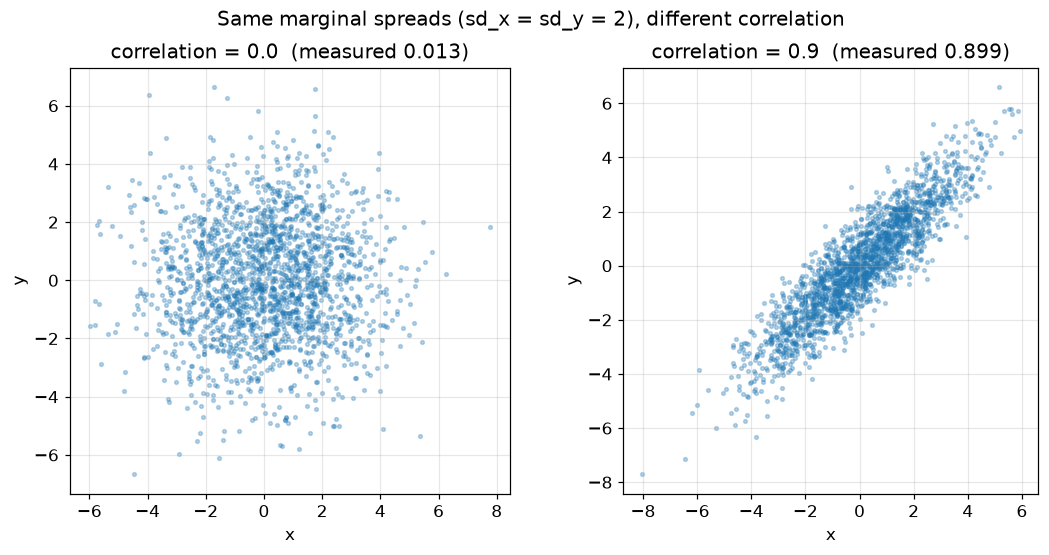

Task 9 passed.


In [22]:
_fig, _axes = compare_correlations(np.random.default_rng(3))

assert len(_axes) == 2, f"expected two Axes, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_aspect() == 1.0, f"panel {_i} does not have equal aspect"
    assert len(_ax.collections) > 0, f"panel {_i} has nothing plotted on it"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), \
    "the figure has no suptitle"

plt.show()
print("Task 9 passed.")

### Question 4 — the off-diagonal entry

Re-run `compare_correlations` mentally, or actually, with the right-hand
correlation set to **-0.9** instead of `0.9`.

Describe what changes in the picture and what does **not**. Specifically:
does the spread of `x` alone change? Does the spread of `y` alone change?
What would you see if you plotted a histogram of just the `x` coordinate
for correlation `0.0`, `0.9` and `-0.9` — could you tell the three cases
apart from that histogram?

Then state the consequence in one sentence: what does this say about
inspecting variables one at a time?

  corr    sd(x)    sd(y)   mean(x)   mean(y)   measured corr
   0.0   2.0139   1.9912    0.0694   -0.0194          0.0134
   0.9   1.9984   2.0066    0.0086   -0.0006          0.8989
  -0.9   1.9597   1.9924   -0.0314    0.0296         -0.8946


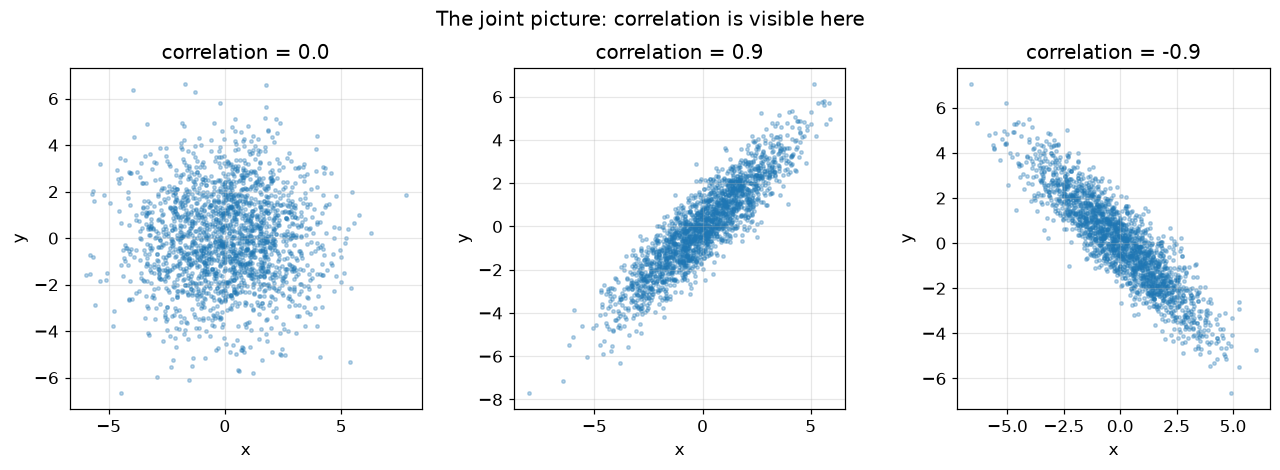

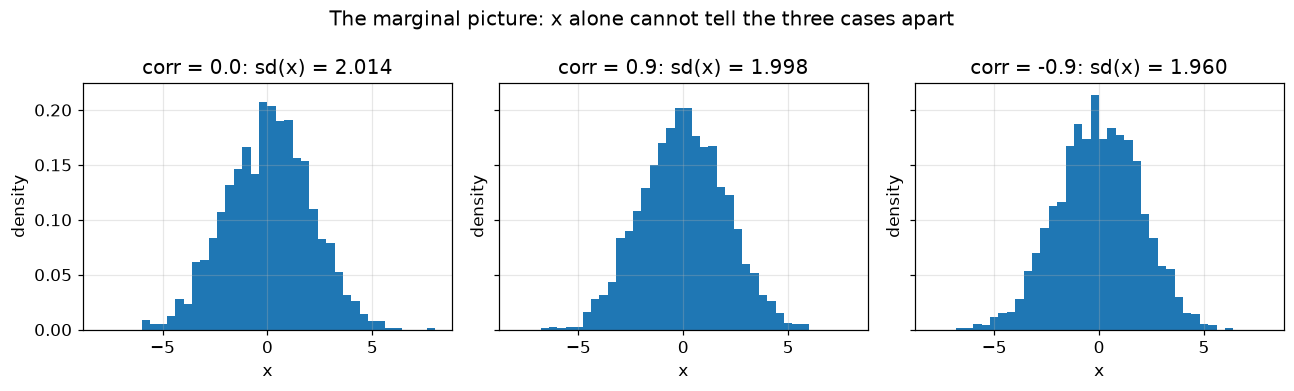

In [23]:
gen = np.random.default_rng(3)
clouds = {}
for correlation in (0.0, 0.9, -0.9):
    pts, _ = correlated_cloud(2.0, 2.0, correlation, 2000, gen)
    clouds[correlation] = pts

print(f"{'corr':>6} {'sd(x)':>8} {'sd(y)':>8} {'mean(x)':>9} {'mean(y)':>9} {'measured corr':>15}")
for correlation, pts in clouds.items():
    print(f"{correlation:>6.1f} {pts[:, 0].std():>8.4f} {pts[:, 1].std():>8.4f} "
          f"{pts[:, 0].mean():>9.4f} {pts[:, 1].mean():>9.4f} "
          f"{np.corrcoef(pts.T)[0, 1]:>15.4f}")

# The scatter plots: the shape of the cloud changes.
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.2))
for ax, (correlation, pts) in zip(axes, clouds.items()):
    ax.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"correlation = {correlation:.1f}")
    ax.set_aspect("equal")
fig.suptitle("The joint picture: correlation is visible here")
fig.tight_layout()
plt.show()

# The histograms of x alone: the marginal is the same in all three.
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6), sharey=True)
bins = np.linspace(-8, 8, 41)
for ax, (correlation, pts) in zip(axes, clouds.items()):
    ax.hist(pts[:, 0], bins=bins, density=True)
    ax.set_xlabel("x")
    ax.set_ylabel("density")
    ax.set_title(f"corr = {correlation:.1f}: sd(x) = {pts[:, 0].std():.3f}")
fig.suptitle("The marginal picture: x alone cannot tell the three cases apart")
fig.tight_layout()
plt.show()


**Answer:**

With `sd_x = sd_y = 2.0` and n = 2000, the three cases measure:

| requested corr | sd(x) | sd(y) | mean(x) | mean(y) | measured corr |
|---|---|---|---|---|---|
| 0.0 | 2.0139 | 1.9912 | 0.0694 | -0.0194 | 0.0134 |
| 0.9 | 1.9984 | 2.0066 | 0.0086 | -0.0006 | 0.8989 |
| -0.9 | 1.9597 | 1.9924 | -0.0314 | 0.0296 | -0.8946 |

**What changes.** The *orientation* of the cloud. At 0.0 it is a circular blob
with no preferred direction. At 0.9 it is a narrow ellipse tilted along the
line y = x: knowing x is large tells me y is probably large. At -0.9 it is the
mirror image, an equally narrow ellipse tilted along y = -x: a large x now
implies a small y. Only the sign of the off-diagonal entry differs between the
last two, and the sign is exactly the direction of the tilt.

**What does not change.** The spread of x alone: 2.0139, 1.9984 and 1.9597,
all estimating the same 2.0 and differing only by sampling noise. Likewise the
spread of y alone: 1.9912, 2.0066, 1.9924. That is structural rather than
coincidental — the diagonal of the covariance matrix is `[sd_x**2, sd_y**2]`
and I never touched it; I only changed the off-diagonal entry. The marginal
distribution of x is N(0, 2) in all three cases, and the marginal of y is too.

**The histogram of x alone.** The three histograms are the same picture up to
sampling noise — same centre, same width, same bell shape (this is the second
figure in the cell above; the three panels are indistinguishable, while the
scatter plots above them are obviously different). **No, I could not tell the
three cases apart from that histogram.** The information that distinguishes
them is not in x and not in y; it lives only in how the two vary *together*,
which a one-variable summary discards by construction. Note that this also
holds for every other marginal summary — mean, sd, skew, quantiles: each is
computed after the other coordinate has been collapsed away.

**The consequence, in one sentence.** Inspecting variables one at a time can
never reveal a relationship between them, so a column-by-column summary — means,
sds, individual histograms — may look identical for datasets whose joint
structure is completely different, and the relationships must be looked for in
the joint view (scatter plot, correlation matrix) on purpose.


## 11. Task 10 — Histograms and the bin count

Applied. Draw one sample three ways and decide which picture to trust.

*see Practice 1 §4.5*

In [24]:
def histogram_grid(sample, bin_counts, density):
    """Plot `sample` as a histogram once per entry in `bin_counts`.

    One Figure, len(bin_counts) Axes in a single row. Panel i uses
    bins=bin_counts[i] and the given `density` flag for every panel.

    Each Axes needs an x label, a y label, and a title naming its bin count.
    The y label must say 'density' when density is True and 'count' when it
    is False, because those are different quantities.

    Return (fig, axes).
    """
    # squeeze=False keeps `axes` an array even when there is a single panel,
    # so the return type does not change with len(bin_counts).
    fig, axes = plt.subplots(1, len(bin_counts),
                             figsize=(4.2 * len(bin_counts), 3.8),
                             squeeze=False)
    axes = axes[0]

    y_label = "density" if density else "count"
    for ax, n_bins in zip(axes, bin_counts):
        ax.hist(sample, bins=n_bins, density=density)
        ax.set_xlabel("value")
        ax.set_ylabel(y_label)
        ax.set_title(f"{n_bins} bins")

    fig.suptitle(f"The same {sample.size} values, density={density}")
    fig.tight_layout()
    return fig, axes


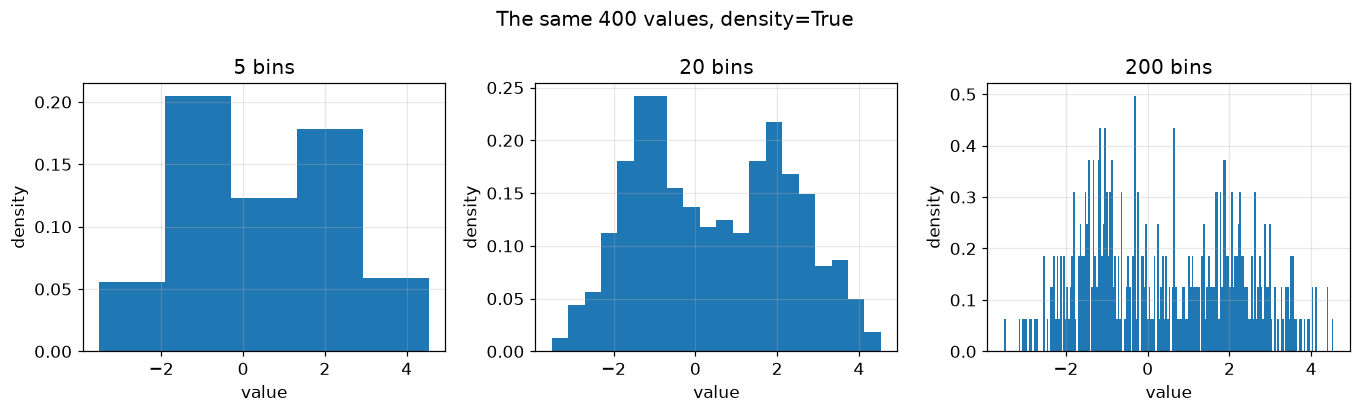

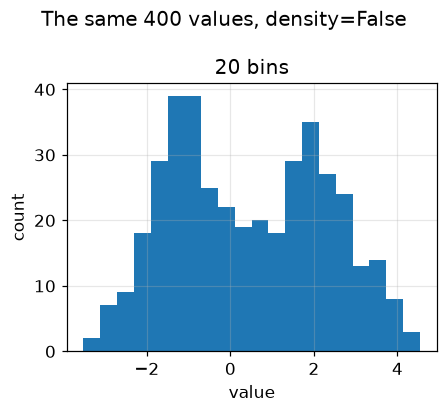

Task 10 passed.


In [25]:
# A deliberately awkward sample: two overlapping normals, 400 points.
_mixture = np.concatenate([
    np.random.default_rng(7).normal(-1.0, 1.0, 200),
    np.random.default_rng(8).normal(2.0, 1.0, 200),
])

_fig, _axes = histogram_grid(_mixture, [5, 20, 200], density=True)

assert len(_axes) == 3, f"expected three panels, got {len(_axes)}"
for _ax in _axes:
    assert _ax.get_xlabel(), "a panel has no x label"
    assert _ax.get_ylabel() == "density", \
        f"with density=True the y axis is a density, not a {_ax.get_ylabel()!r}"
    assert _ax.get_title(), "a panel has no title"
    assert len(_ax.patches) > 0, "a panel has no bars"

_fig_count, _axes_count = histogram_grid(_mixture, [20], density=False)
assert _axes_count[0].get_ylabel() == "count"

plt.show()
print("Task 10 passed.")

### Question 5 — bin count and density

Look at the three panels you just produced from `_mixture`, which was built
from **two** normal components centred at -1 and +2.

**(a)** At which bin count is the two-component structure visible? At which
is it hidden? At 200 bins, are the peaks you see real?

**(b)** Re-run `histogram_grid(_mixture, [5, 20, 200], density=False)` and
compare the y axes with the `density=True` version. The shapes are
identical but the numbers are not. Explain what `density=True` divides by,
and why that makes two samples **of different sizes** comparable on one
axis where raw counts would not be.

**(c)** A colleague shows you a histogram with a clear double peak and
concludes the population has two subgroups. What is the first question you
ask them?

_mixture: n = 400, range [-3.517, 4.538]



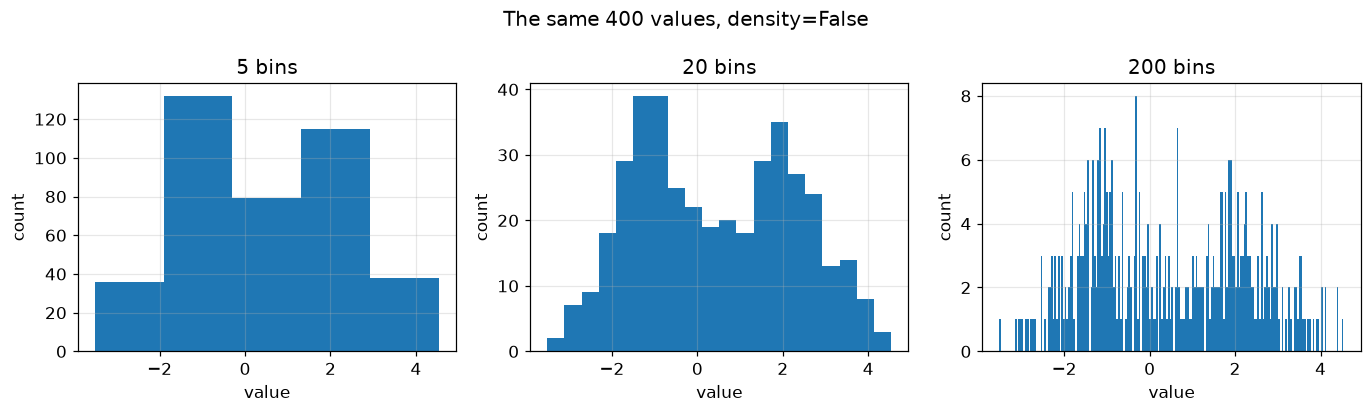

 bins  bin width   tallest bar (count)  tallest bar (density)  empty bins
    5     1.6110                   132                 0.2048           0
   20     0.4027                    39                 0.2421           0
  200     0.0403                     8                 0.4966          42

count/(n*width) for the tallest 20-bin bar: 39/(400*0.4027) = 0.2421
the density histogram reports                : 0.2421
total area under the density histogram       : 1.0000

tallest bar, n=400 vs n=4000 -- counts:  52 vs 473
tallest bar, n=400 vs n=4000 -- density: 0.2364 vs 0.2150


In [26]:
print(f"_mixture: n = {_mixture.size}, range [{_mixture.min():.3f}, {_mixture.max():.3f}]\n")

# (b) the same three panels with raw counts
fig_counts, axes_counts = histogram_grid(_mixture, [5, 20, 200], density=False)
plt.show()

print(f"{'bins':>5} {'bin width':>10} {'tallest bar (count)':>21} {'tallest bar (density)':>22} {'empty bins':>11}")
for n_bins in (5, 20, 200):
    counts, edges = np.histogram(_mixture, bins=n_bins)
    widths = np.diff(edges)
    dens, _ = np.histogram(_mixture, bins=n_bins, density=True)
    print(f"{n_bins:>5} {widths[0]:>10.4f} {counts.max():>21} {dens.max():>22.4f} "
          f"{int((counts == 0).sum()):>11}")

# density = count / (n * bin_width): check that explicitly at 20 bins.
counts, edges = np.histogram(_mixture, bins=20)
dens, _ = np.histogram(_mixture, bins=20, density=True)
width = edges[1] - edges[0]
print(f"\ncount/(n*width) for the tallest 20-bin bar: "
      f"{counts.max()}/({_mixture.size}*{width:.4f}) = {counts.max() / (_mixture.size * width):.4f}")
print(f"the density histogram reports                : {dens[counts.argmax()]:.4f}")
print(f"total area under the density histogram       : {(dens * np.diff(edges)).sum():.4f}")

# Why sizes matter: the same distribution, ten times more points.
big = np.concatenate([
    np.random.default_rng(70).normal(-1.0, 1.0, 2000),
    np.random.default_rng(80).normal(2.0, 1.0, 2000),
])
c_small, _ = np.histogram(_mixture, bins=20, range=(-5, 6))
c_big, _ = np.histogram(big, bins=20, range=(-5, 6))
d_small, _ = np.histogram(_mixture, bins=20, range=(-5, 6), density=True)
d_big, _ = np.histogram(big, bins=20, range=(-5, 6), density=True)
print(f"\ntallest bar, n=400 vs n=4000 -- counts:  {c_small.max()} vs {c_big.max()}")
print(f"tallest bar, n=400 vs n=4000 -- density: {d_small.max():.4f} vs {d_big.max():.4f}")


**Answer:**

`_mixture` is 400 points spanning [-3.517, 4.538], built from components at -1
and +2, each with sd 1.

**(a) Which bin count shows the structure.**

- **5 bins** hides it. The bin width is 1.6110, and the two component centres
  are 3 apart, so a single bin covers most of one component and the gap between
  them; the tallest bar holds 132 of the 400 points. Everything is smoothed into
  one lump and the picture looks unimodal.
- **20 bins** shows it. The width is 0.4027 — small enough to resolve a
  separation of 3, large enough that each bar averages about 20 points, so the
  bar-to-bar noise is small relative to the difference between the peaks. The
  two components are clearly visible.
- **200 bins** is over-resolved and the peaks there are **not real**. The width
  is 0.0403, the tallest bar holds 8 points, and 42 of the 200 bins are empty.
  With about 2 points per bin, a bar of 4 next to a bar of 1 is ordinary Poisson
  noise, not structure. The underlying two-component shape is still faintly
  present, but every local spike in that panel is an artefact of which side of
  an arbitrary boundary a couple of points happened to fall on — redraw the
  sample and the spikes move.

The general trade-off: too few bins biases the picture towards smoothness and
hides real features; too many makes it noisy and invents features. Neither
extreme is more honest than the other, so the bin count is a decision that has
to be made and stated.

**(b) What `density=True` divides by.** It divides each bar's count by
`n * bin_width`, so the bar heights become a probability density — a quantity
per unit of x — and the total **area** (not the total height) is 1. I checked
this directly at 20 bins: the tallest bar holds 39 counts, and
`39 / (400 * 0.4027) = 0.2421`, which is exactly what the density histogram
reports; summing height x width over all bars gives 1.0000.

This is what makes the shapes identical but the numbers different. Compare the
tallest bar across bin counts on the count axis: 132, 39, 8 — it falls as the
bins get narrower, purely because narrower bins catch fewer points, and the
number tells me nothing about the distribution. On the density axis: 0.2048,
0.2421, 0.4966 — all estimating the same underlying density, with the 200-bin
figure inflated by noise rather than by the binning.

**Why this makes samples of different sizes comparable.** Raw counts scale with
n, so a larger sample simply produces taller bars everywhere and the two
histograms cannot be overlaid on one axis. I verified it: the same distribution
at n = 400 and n = 4000, on a fixed set of 20 bins, gives tallest counts of
**52 against 473** — a factor of about 10, which is just the sample-size ratio
and says nothing about shape. The same two on the density scale give **0.2364
against 0.2150**, both estimating the same density, now directly comparable.
Dividing by n removes the sample size; dividing by the bin width removes the
binning choice; what is left is a property of the distribution rather than of
how much data I collected or how I chose to slice it.

**(c) The first question to ask a colleague.** "How many points, and what bin
width — and does the double peak survive when you change it?" Both parts of my
own 200-bin panel are cautionary: with 400 points I can manufacture a dozen
apparent peaks by choosing the bins finely enough. A structure that is real
persists across a range of reasonable bin widths and across a fresh sample; one
that appears at a single setting and vanishes at the next is a property of the
histogram, not of the population. (The follow-up, if it does survive: is there
a known variable that would split the sample into those two groups — sex,
batch, instrument, time period — and does splitting on it actually separate the
peaks? A bimodal histogram is evidence worth explaining, not a conclusion.)


## 12. Task 11 — Open-ended

No assert. This one is marked on the written analysis.

You are given a sample of 5000 measurements below, produced by a generator
whose parameters you are not told. Your task is to **characterise it and
say what you would do with the extreme values**, using only the tools from
Practice 1.

Work through at least the following, and write up what you find:

1. Describe the array: shape, dtype, how much memory it occupies.
2. Compute the mean, the median, the standard deviation, the minimum and
   the maximum. The mean and the median differ noticeably. What does that
   tell you before you have plotted anything?
3. Plot it as a histogram. Choose the bin count deliberately and justify
   your choice in one sentence.
4. Apply the k-sigma rule from Task 5 at k = 3. How many points are
   flagged? Compare that count with the roughly 0.27 % you would expect
   from a normal sample of this size.
5. Now the judgement. Recompute the mean and standard deviation **with the
   flagged points removed**. Report both versions. Then argue, in a
   paragraph, whether the flagged points should be removed — and be
   explicit about what you would need to know about *how the data was
   measured* before you could answer that with any confidence.

A good answer treats step 5 as a question about the measurement process,
not about the numbers. A weak answer deletes the outliers because a rule
said so.

In [27]:
# The data. Do not modify this cell.
_hidden_rng = np.random.default_rng(31337)
mystery_sample = np.concatenate([
    _hidden_rng.normal(10.0, 2.0, 4_900),
    _hidden_rng.uniform(25.0, 60.0, 100),
])
_hidden_rng.shuffle(mystery_sample)

print("mystery_sample is ready:", mystery_sample.shape)

mystery_sample is ready: (5000,)


In [28]:
# --- 1. Describe the array -------------------------------------------------
info = describe_array(mystery_sample)
print("1. LAYOUT")
for key, value in info.items():
    print(f"     {key:>7}: {value}")
print(f"     {'MiB':>7}: {info['nbytes'] / 1024 ** 2:.4f}")

# --- 2. Summary statistics -------------------------------------------------
mean = mystery_sample.mean()
median = np.median(mystery_sample)
sd = mystery_sample.std()
print("\n2. SUMMARY")
print(f"     mean     {mean:9.4f}")
print(f"     median   {median:9.4f}")
print(f"     sd       {sd:9.4f}")
print(f"     min      {mystery_sample.min():9.4f}")
print(f"     max      {mystery_sample.max():9.4f}")
print(f"     mean - median = {mean - median:+.4f}  "
      f"({(mean - median) / sd:+.4f} sd)  -> right-skewed")
print(f"     max is {(mystery_sample.max() - mean) / sd:.2f} sd above the mean")


1. LAYOUT
       dtype: float64
       shape: (5000,)
        ndim: 1
        size: 5000
      nbytes: 40000
         MiB: 0.0381

2. SUMMARY
     mean       10.6311
     median     10.0925
     sd          5.0650
     min         2.5716
     max        59.7279
     mean - median = +0.5386  (+0.1063 sd)  -> right-skewed
     max is 9.69 sd above the mean


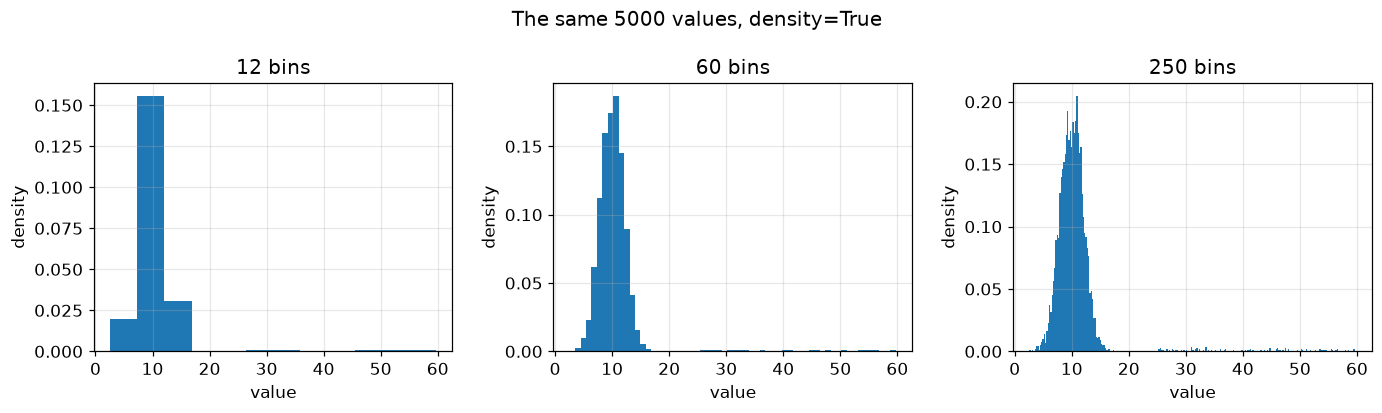

3. BIN COUNT
     sqrt(n)              = 70.7 bins
     Freedman-Diaconis    = 173 bins (width 0.3304, IQR 2.8252)
     chosen               = 60 bins (width 0.9526)


In [29]:
# --- 3. The histogram ------------------------------------------------------
# Bin count: sqrt(5000) ~ 71, and the Freedman-Diaconis rule gives a similar
# figure; I show 60 bins as the main picture, with 12 and 250 beside it to
# show that the conclusion does not depend on that choice.
fig, axes = histogram_grid(mystery_sample, [12, 60, 250], density=True)
plt.show()

iqr = np.percentile(mystery_sample, 75) - np.percentile(mystery_sample, 25)
fd_width = 2 * iqr / mystery_sample.size ** (1 / 3)
fd_bins = int(np.ceil((mystery_sample.max() - mystery_sample.min()) / fd_width))
print(f"3. BIN COUNT")
print(f"     sqrt(n)              = {np.sqrt(mystery_sample.size):.1f} bins")
print(f"     Freedman-Diaconis    = {fd_bins} bins (width {fd_width:.4f}, IQR {iqr:.4f})")
print(f"     chosen               = 60 bins (width "
      f"{(mystery_sample.max() - mystery_sample.min()) / 60:.4f})")


In [30]:
# --- 4. The 3-sigma rule ---------------------------------------------------
mask, flagged = sigma_outliers(mystery_sample, k=3.0)
n_flagged = int(mask.sum())
expected_normal = 0.0027 * mystery_sample.size

print("4. THE 3-SIGMA RULE")
print(f"     flagged            {n_flagged}  ({100 * n_flagged / mystery_sample.size:.2f}%)")
print(f"     expected if normal {expected_normal:.1f}  (0.27%)")
print(f"     ratio              {n_flagged / expected_normal:.1f}x more than a normal sample")
print(f"     flagged range      [{flagged.min():.4f}, {flagged.max():.4f}]")
print(f"     bulk range         [{mystery_sample[~mask].min():.4f}, "
      f"{mystery_sample[~mask].max():.4f}]")
print(f"     gap between the two groups: "
      f"{flagged.min() - mystery_sample[~mask].max():+.4f}")

# Are the flagged points a tail, or a separate group? A tail thins out; a
# second population does not.
for lo, hi in [(20, 25), (25, 30), (30, 40), (40, 50), (50, 60)]:
    n_in = int(((mystery_sample >= lo) & (mystery_sample < hi)).sum())
    print(f"     values in [{lo:>2}, {hi:>2}): {n_in:>4}")


4. THE 3-SIGMA RULE
     flagged            94  (1.88%)
     expected if normal 13.5  (0.27%)
     ratio              7.0x more than a normal sample
     flagged range      [25.9253, 59.7279]
     bulk range         [2.5716, 25.7289]
     gap between the two groups: +0.1964
     values in [20, 25):    0
     values in [25, 30):   17
     values in [30, 40):   29
     values in [40, 50):   26
     values in [50, 60):   28


In [31]:
# --- 5. With and without the flagged points --------------------------------
kept = mystery_sample[~mask]
print("5. WITH AND WITHOUT")
print(f"     {'':<10} {'n':>6} {'mean':>10} {'median':>10} {'sd':>10}")
print(f"     {'all':<10} {mystery_sample.size:>6} {mystery_sample.mean():>10.4f} "
      f"{np.median(mystery_sample):>10.4f} {mystery_sample.std():>10.4f}")
print(f"     {'flagged':<10} {kept.size:>6} {kept.mean():>10.4f} "
      f"{np.median(kept):>10.4f} {kept.std():>10.4f}")
print(f"     {'removed':<10} {'':>6} {kept.mean() - mystery_sample.mean():>+10.4f} "
      f"{np.median(kept) - np.median(mystery_sample):>+10.4f} "
      f"{kept.std() - mystery_sample.std():>+10.4f}")

# Re-applying the rule to the cleaned data: does it stop flagging?
mask2, _ = sigma_outliers(kept, k=3.0)
print(f"\n     3-sigma re-applied to the cleaned data flags {int(mask2.sum())} more points "
      f"({100 * mask2.mean():.2f}%)")
print(f"     and once more:                              "
      f"{int(sigma_outliers(kept[~mask2], k=3.0)[0].sum())}")

# The median barely moves; that is the point of a robust statistic.
print(f"\n     mean   moved {abs(kept.mean() - mystery_sample.mean()) / mystery_sample.std():.3f} sd")
print(f"     median moved {abs(np.median(kept) - np.median(mystery_sample)) / mystery_sample.std():.3f} sd")


5. WITH AND WITHOUT
                     n       mean     median         sd
     all          5000    10.6311    10.0925     5.0650
     flagged      4906    10.0210    10.0419     2.0930
     removed              -0.6101    -0.0506    -2.9720

     3-sigma re-applied to the cleaned data flags 15 more points (0.31%)
     and once more:                              9

     mean   moved 0.120 sd
     median moved 0.010 sd


**write-up:**

### 1. The array

`mystery_sample` is a one-dimensional `float64` array of shape `(5000,)`, that
is 5000 elements at 8 bytes each: `nbytes = 40000`, about **0.038 MiB**. A
trivial amount of memory — but worth noting that the same 5000 measurements in
`float32` would be 20 000 bytes and in Python's own `list` of floats several
times 40 000, which is the reason the array type exists.

### 2. Summary statistics, before any picture

| statistic | value |
|---|---|
| mean | 10.6311 |
| median | 10.0925 |
| sd | 5.0650 |
| min | 2.5716 |
| max | 59.7279 |

The mean sits **0.5386 above the median**, about 0.11 sd. That gap is the
informative number here, and it tells me two things before I have plotted
anything. First, the distribution is **not symmetric**: for a symmetric
distribution the two coincide, so something is pulling the mean up and not
down, which means a right tail — a set of values far above the centre with
nothing balancing them below. Second, the pull is coming from a **small number
of large values** rather than a general rightward shift of the whole
distribution: the median is a rank-based statistic and barely notices how far
away the extremes are, while the mean is a lever arm and responds to their
distance. A body of data shifted right would move both together.

The min and max confirm it and sharpen it considerably. The minimum is 2.5716,
about 1.6 sd below the mean; the maximum is 59.7279, which is **9.69 sd above
it**. Under any distribution remotely like a normal, a 9.7 sd observation in
5000 draws is not merely unlikely, it is impossible in practice — so either the
distribution has a genuinely heavy right tail or the sample contains values
generated by something other than whatever produced the bulk. I cannot yet tell
which, and that distinction is the whole analysis.

### 3. The histogram

I plotted at 12, 60 and 250 bins, taking **60** as the main picture. The
justification in one sentence: `sqrt(5000) = 70.7` and the Freedman-Diaconis
rule gives 173 bins (width 0.3304 from an IQR of 2.8252), and 60 sits at the
conservative end of that range, wide enough (width 0.9526) that bars in the
sparse upper region still carry several points instead of degenerating into the
0-or-1 noise of the 250-bin panel, while narrow enough to resolve the shape of
the central mass. I show the other two beside it precisely so the conclusion
below can be seen not to depend on the choice — the structure I describe is
present at all three settings, which is the test from Question 5.

The picture: a compact, roughly symmetric mound centred near 10 with a width of
about 2, **a completely empty stretch above it**, and then a low, broad, flat
band of points extending out to about 60. That is not the shape of a tail. A
tail decays — each step further out contains fewer points than the last. This
does not decay; it is detached and flat.

### 4. The 3-sigma rule

At k = 3 the rule flags **94 points, 1.88 % of the sample**. A normal sample of
5000 would give about **13.5 points, 0.27 %**. The observed rate is **7 times**
the normal expectation, which by itself says the data is not normal, but says
nothing about why.

The structure of the flagged set is far more informative than its size:

- The flagged values span **[25.9253, 59.7279]**; everything else lies in
  **[2.5716, 25.7289]**.
- Between the two groups there is a **gap of 0.1964** with nothing in it, and,
  more tellingly, the interval [20, 25) contains **exactly 0 points**.
- Counting the flagged region in bands: [25, 30) holds 17, [30, 40) holds 29,
  [40, 50) holds 26, [50, 60) holds 28. Per unit of x that is roughly 3.4, 2.9,
  2.6, 2.8 points — **flat**.

A tail of the central distribution would fall off steeply and would connect to
the bulk continuously. This is flat, and separated from the bulk by an empty
interval five units wide. The evidence therefore points to **two populations**:
a narrow one centred near 10, and a second, roughly uniform one occupying about
25 to 60, containing on the order of 100 points, or 2 % of the data. The 3-sigma
rule found the right points, but the label it attaches to them — "outliers" — is
a description of their position, not a diagnosis of their origin.

### 5. With and without the flagged points

| | n | mean | median | sd |
|---|---|---|---|---|
| all points | 5000 | 10.6311 | 10.0925 | 5.0650 |
| flagged removed | 4906 | 10.0210 | 10.0419 | 2.0930 |
| change | -94 | -0.6101 | -0.0506 | -2.9720 |

Removing 1.88 % of the data moves the mean by 0.61 and **more than halves the
standard deviation**, from 5.0650 to 2.0930. The median moves by 0.0506 — in sd
units, the mean shifts **0.120 sd while the median shifts 0.010 sd**, an order
of magnitude less. That contrast is the practical demonstration of why the
median is called robust: those 94 points carry most of the variance in the
reported sd and almost none of the information in the median.

Two further facts are worth recording before the judgement. Re-applying the same
3-sigma rule to the cleaned data flags **15 more points (0.31 %)**, and applying
it again to *that* flags **9 more**. The rule never terminates, because
removing the extremes shrinks the sd and thereby pulls the threshold in behind
them. Any procedure of the form "delete outliers and repeat" will keep deleting
until told to stop, and where it stops is decided by the analyst's patience, not
by the data. And the dispersion of 5.0650 reported for the full sample is not a
meaningful description of anything: it is neither the spread of the central
group (2.09) nor the spread of the upper group, but an average over a mixture,
and no single point is typically 5 units from the mean.

### The judgement: should the flagged points be removed?

**No — not on this evidence, and the reason is that the question is not about
the numbers at all.** What I have established is statistical: there are two
distinguishable groups, separated by an empty interval, and the smaller one is
roughly flat rather than tail-shaped. What I cannot establish from the array is
the only thing that would justify deletion: whether the upper group came from a
*different measurement process* or from a *different part of the same
population*. The arithmetic is identical in both cases, and the correct action
is opposite in each.

If the second group is a measurement artefact, deleting is right — and the
detached, flat, bounded shape is genuinely suggestive of one, since real-world
mechanisms produce things like a sensor rail, a stuck digit, a unit that changed
mid-collection, a fallback code written when a reading failed, or a batch
recorded on a differently-calibrated instrument. Several of those would produce
exactly a band of values that is disconnected from the bulk and has no internal
shape. If instead the second group is a real subpopulation — a different
species, a faulty production batch, a patient cohort responding differently, a
distinct customer segment — then it is very likely the most interesting thing in
the dataset, and deleting it means discarding the finding and reporting a
central group as if it were the whole. Note which way the incentive points: the
deletion makes the data look cleaner, the sd drop by 59 %, and any downstream
model fit better. That improvement is evidence of nothing.

**What I would need to know about how the data was measured**, specifically:

1. **What the instrument can physically produce.** Its range, resolution, and
   whether 60 is near a limit or a rail. If the device saturates near 60, the
   band is an artefact; if 60 is comfortably inside its range, it is a real
   reading.
2. **Whether any sentinel or fallback values are in use** — codes written when a
   reading fails, and whether they lie in the flagged region.
3. **The units and the collection history.** Was the whole sample collected the
   same way — one instrument, one calibration, one operator, one time window,
   one unit of measurement? Per-record metadata (timestamp, device id, batch,
   site) would settle this immediately: if the 94 flagged points cluster on one
   device, one day, or one operator, that is an artefact and I can say so with
   confidence; if they are spread uniformly across every device and date, that
   is a property of the population.
4. **What the quantity is and whether it is bounded.** A domain expert asked
   "can this quantity legitimately be 50?" often answers in one sentence, and
   that sentence is worth more than any of my statistics.
5. **Whether it reproduces.** A fresh collection that shows the same detached
   band at the same rate is a population; one that does not is a fault specific
   to this batch.

**What I would do in the meantime**, given that none of this is available here:
keep the points; report both summaries side by side rather than one cleaned
number; use the median (10.0925) and the IQR (2.8252) as the headline
description of the central group, since they are almost unchanged by the
question I cannot resolve; state explicitly that the sample appears to be a
mixture of roughly 98 % / 2 % and that the sd of 5.0650 describes the mixture
and not either component; and, if a model has to be fitted, either model the
two components explicitly or fit the central group and report the exclusion as
a documented, justified decision rather than an invisible cleaning step. The
one thing I will not do is delete 94 points because a rule with a threshold I
chose myself put them on the far side of it.


## 13. Before you submit

- Runtime → **Restart and run all**. Every cell must execute in order with
  no error and every assert must pass.
- Every written question has an answer that refers to numbers you actually
  produced.
- Task 11 has a written conclusion, not only code.